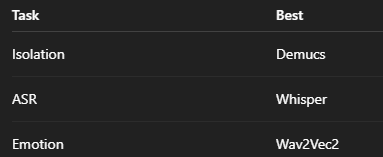

In [4]:
import os
os.system("ffmpeg -version")

0

In [5]:
import os
os.environ["PATH"] += "D:\\Downloads\\ffmpeg-8.1-essentials_build\\bin"

In [6]:
import torchaudio
torchaudio.set_audio_backend("soundfile")

ModuleNotFoundError: No module named 'torchaudio'

In [4]:
import torchaudio
torchaudio.set_audio_backend("soundfile")

from demucs.pretrained import get_model
from demucs.apply import apply_model
import torch

model = get_model(name="htdemucs")
model.eval()

wav, sr = torchaudio.load("input.wav")

# Convert mono → stereo
if wav.shape[0] == 1:
    wav = wav.repeat(2, 1)

sources = apply_model(model, wav[None], device='cpu')[0]

# Extract vocals
vocals = sources[3]

torchaudio.save("clean_voice.wav", vocals, sr)

print("Saved: clean_voice.wav")

C:\Users\Ayush\AppData\Local\Temp\ipykernel_8816\3705446228.py:2: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
d:\Desktop\Amity\SEM-VI\MiniProject\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved: clean_voice.wav


In [5]:
import whisper

# Load model (choose size)
model = whisper.load_model("base")  

# Transcribe
result = model.transcribe("clean_voice.wav")

print(result["text"])

d:\Desktop\Amity\SEM-VI\MiniProject\.venv\lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
d:\Desktop\Amity\SEM-VI\MiniProject\.venv\lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


 I definitely remember once I was little boy and I was sharing my room with my little brother and was to be as young as a mean. It's a sound of when my mother came in in the morning to wake us up and then she walked across each of his kids and said, you have to wake up. It was my brother because we had a bunk bed. It was locked below, then me and then my mother went to the window and took the cover away. It's a sound on the track. Yeah, it was a curtain of hanging. And there's a little roller somewhere. It's a sound I will never forget in my entire life. But it's definitely not the first sound I remember. It's definitely a sound of not a much chanted.


In [6]:
import torch
import transformers

transformers.utils.import_utils._torch_available = True

import librosa
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

model_name = "superb/wav2vec2-base-superb-er"

feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
model = AutoModelForAudioClassification.from_pretrained(model_name)

audio, sr = librosa.load("clean_voice.wav", sr=16000)

inputs = feature_extractor(audio, sampling_rate=16000, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits

predicted_id = torch.argmax(logits, dim=-1).item()
label = model.config.id2label[predicted_id]

print("Emotion:", label)

d:\Desktop\Amity\SEM-VI\MiniProject\.venv\lib\site-packages\transformers\configuration_utils.py:364: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of the model checkpoint at superb/wav2vec2-base-superb-er were not used when initializing Wav2Vec2ForSequenceClassification: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a mo

Emotion: sad


In [1]:
import os
import torch
import librosa
import whisper
import torchaudio
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
from demucs.pretrained import get_model
from demucs.apply import apply_model

# ------------------ STEP 1: Speech Isolation ------------------
def isolate_audio(input_file):
    model = get_model("htdemucs")
    model.eval()

    wav, sr = torchaudio.load(input_file)

    if wav.shape[0] == 1:
        wav = wav.repeat(2, 1)

    sources = apply_model(model, wav[None], device='cpu')[0]
    vocals = sources[3]

    output_path = "clean_voice.wav"
    torchaudio.save(output_path, vocals, sr)

    return output_path

# ------------------ STEP 2: Speech to Text ------------------
def transcribe_audio(audio_file):
    model = whisper.load_model("base")
    result = model.transcribe(audio_file)
    return result["text"]

# ------------------ STEP 3: Emotion Detection ------------------
def detect_emotion(audio_file):
    import transformers
    transformers.utils.import_utils._torch_available = True

    model_name = "superb/wav2vec2-base-superb-er"

    feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
    model = AutoModelForAudioClassification.from_pretrained(model_name)

    audio, sr = librosa.load(audio_file, sr=16000)
    inputs = feature_extractor(audio, sampling_rate=16000, return_tensors="pt")

    with torch.no_grad():
        logits = model(**inputs).logits

    predicted_id = torch.argmax(logits, dim=-1).item()
    return model.config.id2label[predicted_id]

# ------------------ MAIN PIPELINE ------------------
def run_pipeline(input_file):
    clean_audio = isolate_audio(input_file)
    text = transcribe_audio(clean_audio)
    emotion = detect_emotion(clean_audio)

    return {
        "text": text,
        "emotion": emotion,
        "audio": clean_audio
    }

# ------------------ RUN ------------------
if __name__ == "__main__":
    result = run_pipeline("input.wav")
    print(result)

d:\Desktop\Amity\SEM-VI\MiniProject\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Desktop\Amity\SEM-VI\MiniProject\.venv\lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
d:\Desktop\Amity\SEM-VI\MiniProject\.venv\lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
d:\Desktop\Amity\SEM-VI\MiniProject\.venv\lib\site-packages\transformers\configuration_utils.py:364: UserW

{'text': " I definitely remember once I was little boy and I was sharing my room with my little brother and was to be as young as a mean. It's a sound of when my mother came in in the morning to wake us up and then she walked, she asked each of his kids, said, you have to wake up. It was my brother because we had a bunk bed. It was locked below, then me and then my mother went to the window and took the cover away. It's a sound, this... All the track. It was a curtain of hanging in and there's a little roller somewhere. It's a sound I will never forget in my entire life. But it's definitely not the first sound I remember. It's definitely a sound of not a much childhood.", 'emotion': 'sad', 'audio': 'clean_voice.wav'}
